In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages #a reducer used to add messages to the state rather than replacing
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition

import os 
import sys
sys.path.append(os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv()

c:\Users\davis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

In [2]:
class State(TypedDict):
    #Messages have the type "list". The "add_messages" function
    #in the annotation defines how this state key should be updated
    #(in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [3]:
llm = ChatOpenAI(
    model = "gpt-3.5-turbo"
)

In [4]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("What is Langgraph")

{'query': 'What is Langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/en/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph',
   'content': '`LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? The classes from LangChain might be used in LangGraph, but do not HAVE to be used. The packages are different and can be used in isolation, but, in the end, all resources you will find online use both packages hand in hand. `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your application invo

In [5]:
#custom function
def multiply(a:int, b:int) -> int:
    """ Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
    int: output int
    """
    return a*b

In [6]:
tools = [tool, multiply]

In [7]:
llm_with_tools = llm.bind_tools(tools)

In [8]:
llm_with_tools

RunnableBinding(bound=ChatOpenAI(profile={'max_input_tokens': 16385, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': False, 'structured_output': False, 'image_url_inputs': False, 'pdf_inputs': False, 'pdf_tool_message': False, 'image_tool_message': False, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001DABB309940>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001DABB30A3C0>, root_client=<openai.OpenAI object at 0x000001DAB9F32CF0>, root_async_client=<openai.AsyncOpenAI object at 0x000001DABB30A120>, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [9]:
#tool definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [10]:
#Graph
graph_builder = StateGraph(State)

#add nodes
graph_builder.add_node("tools_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

#add edges
graph_builder.add_edge(START, "tools_calling_llm")
graph_builder.add_conditional_edges(
    "tools_calling_llm",
    tools_condition
)
#if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
#if the latest message (result) from assistant is not a tool call -> tools_conditon routes to END
graph_builder.add_edge("tools", "tools_calling_llm")

In [11]:
#compile the graph
graph = graph_builder.compile()

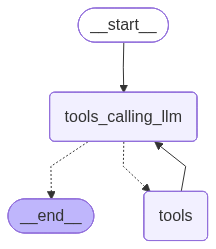

In [12]:
#visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass

In [15]:
response = graph.invoke({"messages":"Give me the recent AI news and then multiply 5 by 78"})

In [16]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 78
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_z6IE1T6BJZ9qwkt7KYjFmC5t)
 Call ID: call_z6IE1T6BJZ9qwkt7KYjFmC5t
  Args:
    query: recent AI news
    search_depth: advanced
    topic: general
    time_range: week
  multiply (call_CKzwUVROlZ1gBCWHE9rxh3wZ)
 Call ID: call_CKzwUVROlZ1gBCWHE9rxh3wZ
  Args:
    a: 5
    b: 78
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.yeschat.ai/gpts-9t557fXdeRL-Recent-AI-News", "title": "Recent AI News-Free, Customized AI Updates", "content": "Title: Recent AI News-Free, Customized AI Updates\n# Recent AI News- Customized AI Updates. Welcome to Recent AI News! ## Overview of Recen

In [17]:
response

{'messages': [HumanMessage(content='Give me the recent AI news and then multiply 5 by 78', additional_kwargs={}, response_metadata={}, id='b58aac23-3591-4374-b286-e7d6c7dd16de'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 1297, 'total_tokens': 1361, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DgtYwDPrZrhLaxCtuLaZzUigiJa0M', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e3b8f-ea8e-7940-bcd0-17179e4a1fc1-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'search_depth': 'advanced', 'topic': 'general', 'time_range': 'week'}, 'id': 'call_z6IE1T6BJZ9qwkt7KYjFmC